# Growing a marketplace without breaking it

### A study of orders, delivery and customer satisfaction

---

An online marketplace connects thousands of small sellers to customers spread
across Brazil. Leadership wants to grow it. The worry is that growth and
customer experience pull against each other: sign up sellers quickly and sales
rise, but late deliveries and bad products start driving customers away. Police
the slow sellers and quality improves, but the catalogue shrinks and growth
stalls.

Right now those calls are being made on instinct. This notebook works through
the order data to see whether that trade-off is actually real, and if so, where.

**What I set out to answer**

1. Is growth already costing satisfaction, or is it only a risk?
2. What actually makes someone leave a one-star review?
3. If it's delivery, which part — the seller packing it, or the carrier moving it?
4. Which categories, regions and sellers carry the most risk?
5. What would each possible fix cost, and what would it buy?

The short version of what I found is at the bottom. I'd rather you read the
working first, because a couple of the results surprised me and the reasoning
matters more than the conclusion.

**Dataset:** 99,441 orders from a Brazilian e-commerce marketplace, spanning
September 2016 to October 2018, split across nine relational tables plus two
marketing tables.


---
## How to run this

You need the eleven CSV files. Pick whichever is easiest:

- **Upload a zip** — run the next cell and choose your `Project Dataset.zip`
- **Google Drive** — put the CSVs in a Drive folder and set `DATA_DIR` to it
- **Local Jupyter** — put the CSVs in a folder next to this notebook

The loader below tries each in turn, so usually you can just run everything
top to bottom.


In [1]:
# Dependencies. Colab already has all of these, so this is normally a no-op.
import sys, subprocess

for pkg in ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"]:
    try:
        __import__(pkg if pkg != "scikit-learn" else "sklearn")
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Ready.")


Ready.


In [2]:
import os, re, glob, zipfile, warnings, textwrap
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

IN_COLAB = "google.colab" in sys.modules


def find_data():
    """Locate the CSVs, trying the most convenient source first."""
    # Somewhere obvious already?
    for guess in [".", "data", "data/raw", "Project Dataset",
                  "/content/data", "/content"]:
        if glob.glob(f"{guess}/**/orders_dataset.csv", recursive=True):
            hit = glob.glob(f"{guess}/**/orders_dataset.csv", recursive=True)[0]
            return str(Path(hit).parent)

    # Ask for an upload.
    if IN_COLAB:
        from google.colab import files
        print("Upload the dataset zip (or the CSVs directly).")
        up = files.upload()
        for name in up:
            if name.endswith(".zip"):
                with zipfile.ZipFile(name) as z:
                    z.extractall("/content/data")
        hits = glob.glob("/content/**/orders_dataset.csv", recursive=True)
        if hits:
            return str(Path(hits[0]).parent)

    raise FileNotFoundError(
        "Couldn't find orders_dataset.csv. Set DATA_DIR manually below."
    )


DATA_DIR = find_data()          # <- override this line if you know the path
print("Reading from:", DATA_DIR)


Reading from: data/raw


In [3]:
# One dict holding every table. Filenames in the archive sometimes carry
# stray spaces, so match on the stem rather than the exact name.
WANTED = ["orders", "order_items", "order_payments", "order_reviews",
          "customers", "sellers", "products", "product_category_name_translation",
          "geolocation", "marketing_qualified_leads", "closed_deals"]

raw = {}
for path in glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True):
    stem = Path(path).stem.strip().replace("_dataset", "")
    if stem in WANTED:
        raw[stem] = pd.read_csv(path)

missing = set(WANTED) - set(raw)
print(f"Loaded {len(raw)} tables." + (f"  MISSING: {missing}" if missing else ""))

for name, df in sorted(raw.items()):
    print(f"  {name:36s} {len(df):>9,} rows  x {df.shape[1]:>2} cols")


Loaded 11 tables.
  closed_deals                               842 rows  x 14 cols
  customers                               99,441 rows  x  5 cols
  geolocation                          1,000,163 rows  x  5 cols
  marketing_qualified_leads                8,000 rows  x  4 cols
  order_items                            112,650 rows  x  7 cols
  order_payments                         103,886 rows  x  5 cols
  order_reviews                           99,224 rows  x  7 cols
  orders                                  99,441 rows  x  8 cols
  product_category_name_translation           71 rows  x  2 cols
  products                                32,951 rows  x  9 cols
  sellers                                  3,095 rows  x  4 cols


---
## A note on the charts

I'm fixing the styling once, up front, so I'm not fiddling with colours in
every cell. Two rules I stuck to throughout:

**Colour means something or it isn't used.** Red is always a bad outcome, green
is always a good one, amber means "look here". Nothing is coloured just to
brighten up a chart. That sounds pedantic but it's the difference between a
reader decoding your legend and a reader just seeing the point.

**No chart junk.** No 3D, no gradients, no gridlines fighting the data.


In [4]:
NAVY, AMBER, RED, GREEN = "#1f3a68", "#e8833a", "#c1462f", "#2e8b6f"
GREY, LINE = "#8a93a5", "#e6e9ef"

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.titlecolor": NAVY,
    "axes.titlepad": 14,
    "axes.labelcolor": "#2b3245",
    "axes.edgecolor": LINE,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": LINE,
    "grid.linewidth": 0.8,
    "xtick.color": GREY,
    "ytick.color": GREY,
    "legend.frameon": False,
    "figure.facecolor": "white",
})
for side in ["top", "right"]:
    plt.rcParams[f"axes.spines.{side}"] = False


def label_bars(ax, fmt="{:.2f}", pad=3):
    """Put the value on top of each bar. Saves the reader squinting at an axis."""
    for p in ax.patches:
        if np.isfinite(p.get_height()):
            ax.annotate(fmt.format(p.get_height()),
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha="center", va="bottom", fontsize=10,
                        color="#2b3245", xytext=(0, pad),
                        textcoords="offset points")


print("Style set.")


Style set.


---
# 1. Getting oriented

Before touching anything I want to know how the tables connect and, more
importantly, what the grain of each one is. Getting the grain wrong is how you
end up double-counting revenue and not noticing.


In [5]:
print("orders        :", raw["orders"].order_id.nunique(), "unique ids /",
      len(raw["orders"]), "rows")
print("order_items   :", raw["order_items"].order_id.nunique(), "unique orders /",
      len(raw["order_items"]), "rows")
print("order_reviews :", raw["order_reviews"].order_id.nunique(), "unique orders /",
      len(raw["order_reviews"]), "rows")
print("customers     :", raw["customers"].customer_id.nunique(), "customer_id /",
      raw["customers"].customer_unique_id.nunique(), "customer_unique_id")


orders        : 99441 unique ids / 99441 rows
order_items   : 98666 unique orders / 112650 rows
order_reviews : 98673 unique orders / 99224 rows
customers     : 99441 customer_id / 96096 customer_unique_id


Three things fall out of that, and all three matter later.

**`order_items` has more rows than orders.** An order can contain several items,
possibly from different sellers. So anything at order level needs aggregating
first, and "number of orders" and "number of items" are different questions.

**`order_reviews` has more rows than it has distinct orders.** A few hundred
orders got surveyed twice. If I join naively I'll silently duplicate those
orders and weight them double.

**`customer_id` is not a person.** There are as many customer_ids as there are
orders, because a new one is minted per order. `customer_unique_id` is the
actual person. I nearly missed this, and it would have made repeat-purchase
analysis meaningless.


In [6]:
dupes = raw["order_reviews"].order_id.duplicated().sum()
print(f"Orders with more than one review: {dupes}")

# Keep the earliest review per order: it's the one reflecting the delivery
# the customer actually just had.
reviews = (raw["order_reviews"]
           .sort_values(["order_id", "review_creation_date"])
           .drop_duplicates("order_id", keep="first"))

print(f"After deduplication: {len(reviews):,} reviews")


Orders with more than one review: 551


After deduplication: 98,673 reviews


---
# 2. Data quality

I'd rather find the problems now than have one surface halfway through a
presentation. Going table by table looking for missing values, contradictions
and things that are physically impossible.


In [7]:
orders = raw["orders"].copy()
TS = ["order_purchase_timestamp", "order_approved_at",
      "order_delivered_carrier_date", "order_delivered_customer_date",
      "order_estimated_delivery_date"]
for c in TS:
    orders[c] = pd.to_datetime(orders[c])

print("Missing timestamps:")
for c in TS:
    n = orders[c].isna().sum()
    print(f"  {c:32s} {n:>6,}  ({n/len(orders):.2%})")

print("\nOrder status:")
print(orders.order_status.value_counts())


Missing timestamps:
  order_purchase_timestamp              0  (0.00%)
  order_approved_at                   160  (0.16%)
  order_delivered_carrier_date      1,783  (1.79%)
  order_delivered_customer_date     2,965  (2.98%)
  order_estimated_delivery_date         0  (0.00%)

Order status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


2,965 orders have no delivery date. Most of those are orders that simply never
completed — shipped, cancelled, unavailable. Fine. But it's worth checking
whether any order claims to be delivered while having no delivery date, because
that's a straight contradiction.


In [8]:
contradiction = orders[(orders.order_status == "delivered")
                       & orders.order_delivered_customer_date.isna()]
print(f"Status says 'delivered' but no delivery date: {len(contradiction)}")

# Impossible orderings: handed to the carrier before payment cleared, or
# delivered to the customer before the carrier ever received it.
bad_handover = (orders.order_delivered_carrier_date
                < orders.order_approved_at).sum()
bad_delivery = (orders.order_delivered_customer_date
                < orders.order_delivered_carrier_date).sum()
print(f"Carrier pickup before payment approval:   {bad_handover:,}")
print(f"Delivered before carrier received it:     {bad_delivery:,}")


Status says 'delivered' but no delivery date: 8
Carrier pickup before payment approval:   1,359
Delivered before carrier received it:     23


So there are 1,382 orders where the lifecycle timestamps are out of order. These
aren't real events, they're recording faults — probably batch jobs writing
timestamps after the fact.

I'm not going to throw those orders away, because the purchase-to-delivery time
is still perfectly valid for them. What I'll do is null out the individual stage
durations that come back negative, so they can't drag the stage averages around.
That's 1.4% of orders affected on one field each, rather than 1.4% of orders
deleted.

**The decision I want to flag**, because it's the one most likely to produce a
confidently wrong answer: when an order has no delivery date, "was it late?"
must be *unknown*, not *no*. If I default it to False, every undelivered order
counts as on-time and the on-time rate looks better than it is. I've kept it as
NaN throughout.


---
# 3. Building one table to work from

The relational structure is good for storage and awkward for analysis. I'm
flattening it into a single row per order, carrying everything I'll need.

The features I care most about are the ones that split the delivery journey
into stages, because that's what will tell me whether a delay belongs to the
seller or the carrier:

| Stage | From | To | Whose fault |
|---|---|---|---|
| Approval | purchase | payment cleared | payment system |
| Handling | payment cleared | carrier collects | **the seller** |
| Transit | carrier collects | customer receives | **the carrier** |

Plus `delay_days`, which is delivery date minus promised date. Positive means
late. That's the number the customer actually experiences, because they don't
know how long it "should" have taken, only what they were told at checkout.


In [9]:
# --- item level: roll up to one row per order ---------------------------
items = raw["order_items"].merge(
    raw["products"][["product_id", "product_category_name"]],
    on="product_id", how="left")
items = items.merge(raw["product_category_name_translation"],
                    on="product_category_name", how="left")
items = items.merge(raw["sellers"][["seller_id", "seller_state"]],
                    on="seller_id", how="left")

# Category can be missing. Label it rather than dropping the order.
items["category"] = (items.product_category_name_english
                     .fillna(items.product_category_name)
                     .fillna("unknown"))

# When an order spans several products, call the most expensive one the
# "main" one. Arbitrary tie-breaks would make the category view unstable.
items = items.sort_values(["order_id", "price"], ascending=[True, False])

by_order = items.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    n_sellers=("seller_id", "nunique"),
    item_total=("price", "sum"),
    freight_total=("freight_value", "sum"),
    main_category=("category", "first"),
    main_seller=("seller_id", "first"),
    seller_state=("seller_state", "first"),
).reset_index()

print(f"{len(by_order):,} orders with items")
by_order.head(3)


98,666 orders with items


,order_id,n_items,n_sellers,item_total,freight_total,main_category,main_seller,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,58.9,13.29,cool_stuff,48436dade18ac8b2bce089ec2a041202,SP
1,00018f77f2f0320c557190d7a144bdd3,1,1,239.9,19.93,pet_shop,dd7ddc04e1b6c2c614352b383efe2d36,SP
2,000229ec398224ef6ca0657da4fc703e,1,1,199.0,17.87,furniture_decor,5b51032eddd242adc84c38acab88f23d,MG


In [10]:
# --- payments ------------------------------------------------------------
pay = raw["order_payments"].sort_values(["order_id", "payment_value"],
                                        ascending=[True, False])
by_pay = pay.groupby("order_id").agg(
    payment_value=("payment_value", "sum"),
    installments=("payment_installments", "max"),
    payment_type=("payment_type", "first"),
).reset_index()

# --- stitch it together --------------------------------------------------
df = (orders
      .merge(raw["customers"][["customer_id", "customer_unique_id",
                               "customer_state", "customer_city"]],
             on="customer_id", how="left")
      .merge(by_order, on="order_id", how="left")
      .merge(by_pay, on="order_id", how="left")
      .merge(reviews[["order_id", "review_score", "review_comment_message"]],
             on="order_id", how="left"))

print(f"{len(df):,} rows, {df.shape[1]} columns")
assert df.order_id.is_unique, "grain broken somewhere"
print("One row per order. Good.")


99,441 rows, 23 columns
One row per order. Good.


In [11]:
DAY = 86400

def days_between(a, b):
    return (b - a).dt.total_seconds() / DAY

df["approval_days"] = days_between(df.order_purchase_timestamp, df.order_approved_at)
df["handling_days"] = days_between(df.order_approved_at, df.order_delivered_carrier_date)
df["transit_days"]  = days_between(df.order_delivered_carrier_date,
                                   df.order_delivered_customer_date)
df["delivery_days"] = days_between(df.order_purchase_timestamp,
                                   df.order_delivered_customer_date)
df["promised_days"] = days_between(df.order_purchase_timestamp,
                                   df.order_estimated_delivery_date)
df["delay_days"]    = days_between(df.order_estimated_delivery_date,
                                   df.order_delivered_customer_date)

# The timestamp faults found earlier: null the impossible stage, keep the order.
for c in ["approval_days", "handling_days", "transit_days"]:
    df.loc[df[c] < 0, c] = np.nan

delivered = df.order_delivered_customer_date.notna()

# NaN, not False, when we don't know. See the note in section 2.
df["is_late"] = np.where(delivered, (df.delay_days > 0).astype(float), np.nan)
df["is_bad"]  = np.where(df.review_score.notna(),
                         (df.review_score <= 2).astype(float), np.nan)

df["is_delivered"]    = df.order_status.eq("delivered") & delivered
df["multi_seller"]    = df.n_sellers > 1
df["cross_state"]     = df.seller_state != df.customer_state
df["freight_ratio"]   = df.freight_total / df.item_total.replace(0, np.nan)
df["month"]           = df.order_purchase_timestamp.dt.to_period("M").dt.to_timestamp()
df["padding_days"]    = df.promised_days - df.delivery_days

print(df[["delivery_days", "handling_days", "transit_days",
          "delay_days"]].describe().round(1))


       delivery_days  handling_days  transit_days  delay_days
count        96476.0        96285.0       96452.0     96476.0
mean            12.6            2.9           9.3       -11.2
std              9.5            3.5           8.8        10.2
min              0.5            0.0           0.0      -146.0
25%              6.8            0.9           4.1       -16.2
50%             10.2            1.9           7.1       -11.9
75%             15.7            3.6          12.0        -6.4
max            209.6          125.8         205.2       189.0


### Defining the population once

Every satisfaction number from here on is computed on the same set of orders:
**delivered, and carrying a review**. I'm defining it in one place so that no
two charts in this notebook can quietly disagree about their denominator. It's a
small discipline that saves a lot of embarrassment.

I'm also trimming to 2017-01 through 2018-08. The months either side have only a
handful of orders and they make every trend line look dramatic for no reason.


In [12]:
base = df[df.is_delivered & df.review_score.notna()].copy()
base = base[(base.order_purchase_timestamp >= "2017-01-01")
            & (base.order_purchase_timestamp <= "2018-08-31")]

print(f"Working population: {len(base):,} orders")
print(f"  from {len(df):,} total")
print(f"  average review score: {base.review_score.mean():.2f}")
print(f"  late deliveries:      {base.is_late.mean():.1%}")


Working population: 95,560 orders
  from 99,441 total
  average review score: 4.16
  late deliveries:      8.0%


---
# 4. Is growth already costing satisfaction?

The first question. If the average score is falling as the marketplace grows,
the trade-off is real and already happening.


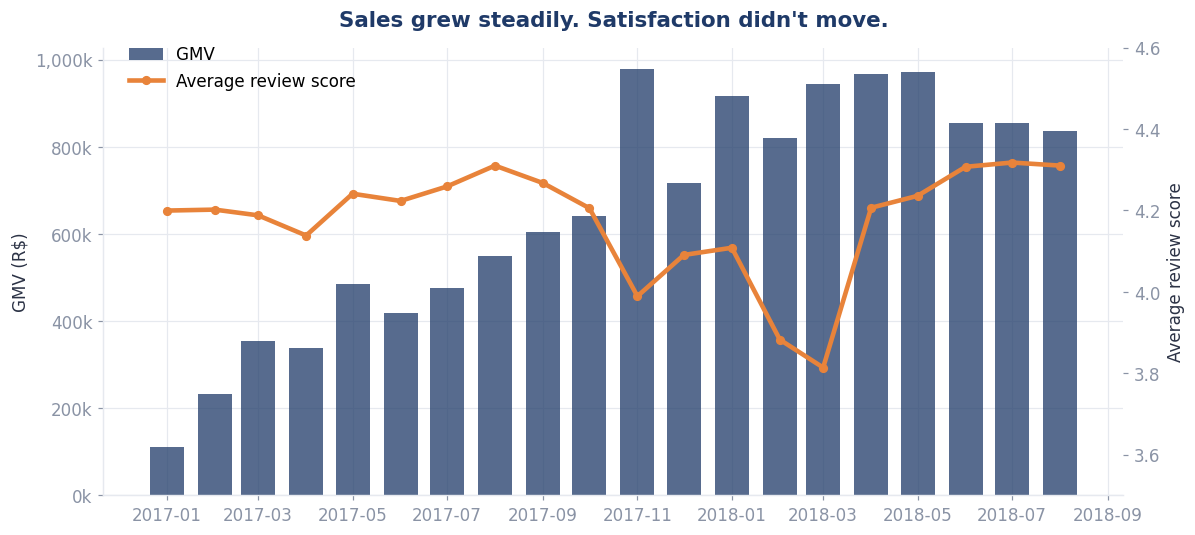

In [13]:
monthly = base.groupby("month").agg(
    gmv=("item_total", "sum"),
    orders=("order_id", "size"),
    avg_score=("review_score", "mean"),
    late_rate=("is_late", "mean"),
    bad_rate=("is_bad", "mean"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(monthly.month, monthly.gmv, width=22, color=NAVY, alpha=0.75, label="GMV")
ax1.set_ylabel("GMV (R$)")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))

ax2 = ax1.twinx()
ax2.plot(monthly.month, monthly.avg_score, color=AMBER, lw=3,
         marker="o", ms=5, label="Average review score")
ax2.set_ylim(3.5, 4.6)
ax2.set_ylabel("Average review score")
ax2.grid(False)

ax1.set_title("Sales grew steadily. Satisfaction didn't move.")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.93))
plt.tight_layout(); plt.show()


Sales climbed roughly tenfold across the period and the average score sat around
4.16 the whole way. Taken at face value, there's no problem here at all.

I don't think that's the right reading, and it took me a while to articulate
why. A national average across 27 states and 70 product categories is an
enormously blunt instrument. A flat average is exactly what you'd see if one
region were deteriorating badly while a bigger one stayed healthy — São Paulo is
42% of orders on its own, so it can hold the mean up while everything else
slides.

So the answer to question one is: not visibly, and that's precisely why it's
worth looking harder. I stopped tracking the mean after this chart and started
looking at where the bad reviews actually cluster.


---
# 5. What makes someone leave a one-star review?

Starting with the shape of the outcome itself, because it determines how I
should model it.


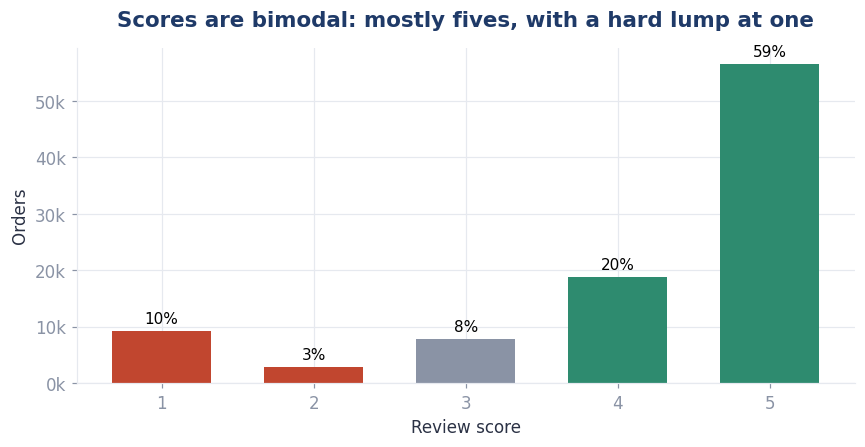

Mean score: 4.16
Share 1-2 stars: 12.8%


In [14]:
dist = base.review_score.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4.2))
colors = [RED, RED, GREY, GREEN, GREEN]
ax.bar(dist.index, dist.values, color=colors, width=0.65)
for x, v in dist.items():
    ax.annotate(f"{v/dist.sum():.0%}", (x, v), ha="center", va="bottom",
                xytext=(0, 3), textcoords="offset points", fontsize=10)
ax.set_xlabel("Review score"); ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))
ax.set_title("Scores are bimodal: mostly fives, with a hard lump at one")
plt.tight_layout(); plt.show()

print(f"Mean score: {base.review_score.mean():.2f}")
print(f"Share 1-2 stars: {base.is_bad.mean():.1%}")


This shape changed how I approached the rest of the analysis.

57% of reviews are five stars and 12% are one star. Very little sits in the
middle. So the mean of 4.16 describes a region where almost no actual review
falls — it's the average of a crowd standing at two ends of a room.

That means predicting the average score is close to meaningless. What matters
operationally is whether an order produces a **detractor**: someone who leaves
one or two stars. I'll treat that as the outcome from here on. It's binary, it's
well-defined, and it maps onto something you can actually act on.


In [15]:
comparison = base.groupby("is_late").agg(
    orders=("order_id", "size"),
    avg_score=("review_score", "mean"),
    one_star=("review_score", lambda s: (s == 1).mean()),
    bad_rate=("is_bad", "mean"),
).rename(index={0.0: "On time", 1.0: "Late"})

print(comparison.round(3))


         orders  avg_score  one_star  bad_rate
is_late                                       
On time   87902      4.295     0.066     0.092
Late       7658      2.568     0.461     0.540


There it is. On-time orders average 4.30 stars. Late ones average 2.57.

That's not a nudge, it's a collapse — 1.7 stars, from a single binary. Nothing
else I tested in this dataset comes close to that effect size. 46% of late
orders get a *one-star* review, against 7% of on-time ones.

Before building anything on top of this I wanted to know the shape of it. Is it
a gradual slide, where every extra day costs you a little? Or something else?


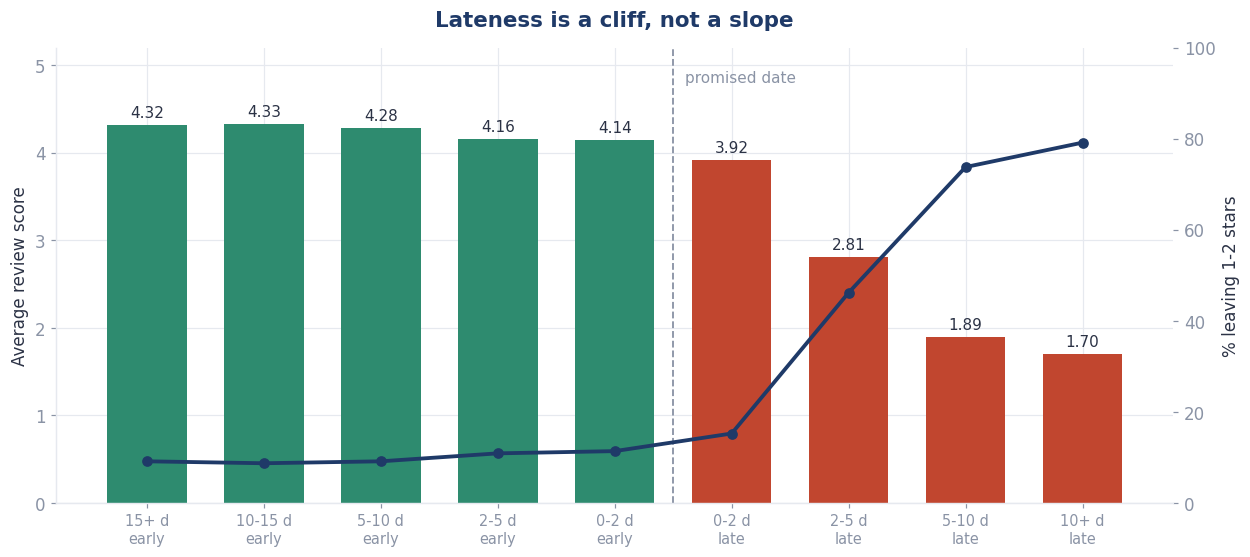

  delay_bucket  orders  avg_score  bad_rate
  15+ d\nearly   29209      4.320     0.091
10-15 d\nearly   27443      4.328     0.087
 5-10 d\nearly   22437      4.279     0.091
  2-5 d\nearly    5824      4.158     0.109
  0-2 d\nearly    2989      4.142     0.114
   0-2 d\nlate    2099      3.918     0.152
   2-5 d\nlate    1468      2.809     0.462
  5-10 d\nlate    1861      1.893     0.738
   10+ d\nlate    2230      1.702     0.791


In [16]:
bins   = [-1e4, -15, -10, -5, -2, 0, 2, 5, 10, 1e4]
labels = ["15+ d\nearly", "10-15 d\nearly", "5-10 d\nearly", "2-5 d\nearly",
          "0-2 d\nearly", "0-2 d\nlate", "2-5 d\nlate", "5-10 d\nlate",
          "10+ d\nlate"]
base["delay_bucket"] = pd.cut(base.delay_days, bins=bins, labels=labels)

curve = base.groupby("delay_bucket", observed=True).agg(
    orders=("order_id", "size"),
    avg_score=("review_score", "mean"),
    bad_rate=("is_bad", "mean"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(11.5, 5.2))
bar_colors = [GREEN if "early" in str(b) else RED for b in curve.delay_bucket]
ax1.bar(range(len(curve)), curve.avg_score, color=bar_colors, width=0.68)
label_bars(ax1)
ax1.set_xticks(range(len(curve)))
ax1.set_xticklabels(curve.delay_bucket, fontsize=9.5)
ax1.set_ylim(0, 5.2); ax1.set_ylabel("Average review score")

ax2 = ax1.twinx()
ax2.plot(range(len(curve)), curve.bad_rate * 100, color=NAVY, lw=2.5,
         marker="o", ms=6)
ax2.set_ylabel("% leaving 1-2 stars"); ax2.set_ylim(0, 100); ax2.grid(False)

ax1.axvline(4.5, color=GREY, ls="--", lw=1.2)
ax1.text(4.6, 4.8, "promised date", color=GREY, fontsize=10)
ax1.set_title("Lateness is a cliff, not a slope")
plt.tight_layout(); plt.show()

print(curve.round(3).to_string(index=False))


This is the most useful chart in the notebook, and it says two separate things.

**Look at the left half.** Delivering fifteen days early (4.32) scores no better
than delivering two days early (4.14). Once you're comfortably inside the
promise, being faster buys you almost nothing. Any investment aimed at making
already-fast deliveries faster is wasted.

**Now the right half.** Two days late is survivable at 3.92. Five to ten days
late collapses to 1.89. The damage is concentrated entirely in the tail.

Together those point somewhere quite specific: the goal isn't to reduce average
delivery time. It's to eliminate the worst outcomes. A programme that shaved a
day off every delivery in the country would achieve less than one that fixed the
slowest 5%.

That reframing is worth more than the individual numbers, I think. It changes
what you'd fund.


---
# 6. Whose delay is it?

The brief talks about slow sellers. That's the intuitive culprit — a seller sits
on an order for a week and the customer suffers. Let's check whether the data
agrees, by splitting the journey into its stages.


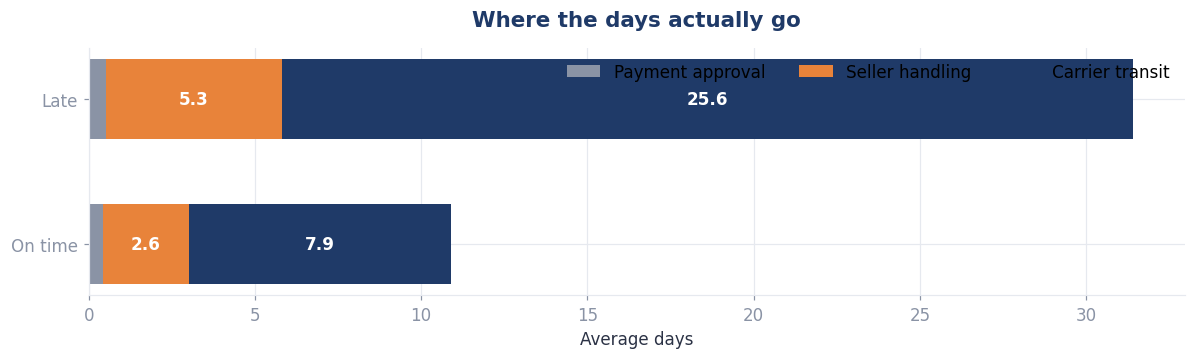

         Payment approval  Seller handling  Carrier transit
group                                                      
On time              0.42             2.60             7.89
Late                 0.51             5.31            25.57

Correlation with review score:
review_score     1.000
handling_days   -0.159
transit_days    -0.300
delivery_days   -0.334
Name: review_score, dtype: float64


In [17]:
stages = []
for label, sub in [("On time", base[base.is_late == 0]),
                   ("Late",    base[base.is_late == 1])]:
    stages.append({
        "group": label,
        "Payment approval": sub.approval_days.mean(),
        "Seller handling":  sub.handling_days.mean(),
        "Carrier transit":  sub.transit_days.mean(),
    })
stages = pd.DataFrame(stages).set_index("group")

fig, ax = plt.subplots(figsize=(11, 3.4))
left = np.zeros(len(stages))
for col, color in [("Payment approval", GREY), ("Seller handling", AMBER),
                   ("Carrier transit", NAVY)]:
    ax.barh(stages.index, stages[col], left=left, color=color, label=col,
            height=0.55)
    for i, (v, l) in enumerate(zip(stages[col], left)):
        if v > 1:
            ax.text(l + v/2, i, f"{v:.1f}", ha="center", va="center",
                    color="white", fontsize=11, fontweight="bold")
    left += stages[col].values

ax.set_xlabel("Average days"); ax.legend(ncol=3, loc="upper right")
ax.set_title("Where the days actually go")
plt.tight_layout(); plt.show()

print(stages.round(2))
print("\nCorrelation with review score:")
print(base[["review_score", "handling_days", "transit_days",
            "delivery_days"]].corr()["review_score"].round(3))


This was the result that changed my mind about the whole project.

Sellers hand parcels to the carrier in **2.8 days** on average. The carrier then
holds them for **9.3 days**. On late orders the seller adds 5.3 days and the
carrier adds 25.6.

And the correlations point the same way: −0.16 for seller handling against
−0.30 for carrier transit. The carrier holds the parcel more than three times
as long and matters about twice as much to the outcome.

So the lever in the brief — crack down on slow sellers — is aimed at the smaller
half of the problem. Not a useless lever, but not the main one, and the
distinction is worth real money because coaching sellers and negotiating with
carriers are completely different programmes.

I was cautious about this finding because it's convenient — it's the kind of
thing that sounds clever in a presentation. So I went looking for an independent
way to check it, which is section 9.


---
# 7. Geography

Brazil is large. I'd expect distance to be most of the transit story.


In [18]:
geo = raw["geolocation"]
geo = geo[(geo.geolocation_lat.between(-34, 5.3))
          & (geo.geolocation_lng.between(-74, -34.8))]
centroid = geo.groupby("geolocation_zip_code_prefix")[
    ["geolocation_lat", "geolocation_lng"]].median()

print(f"Geolocation rows: {len(raw['geolocation']):,} "
      f"-> {len(centroid):,} zip prefixes")
print(f"Dropped {len(raw['geolocation']) - len(geo):,} points outside Brazil")


Geolocation rows: 1,000,163 -> 19,010 zip prefixes
Dropped 47 points outside Brazil


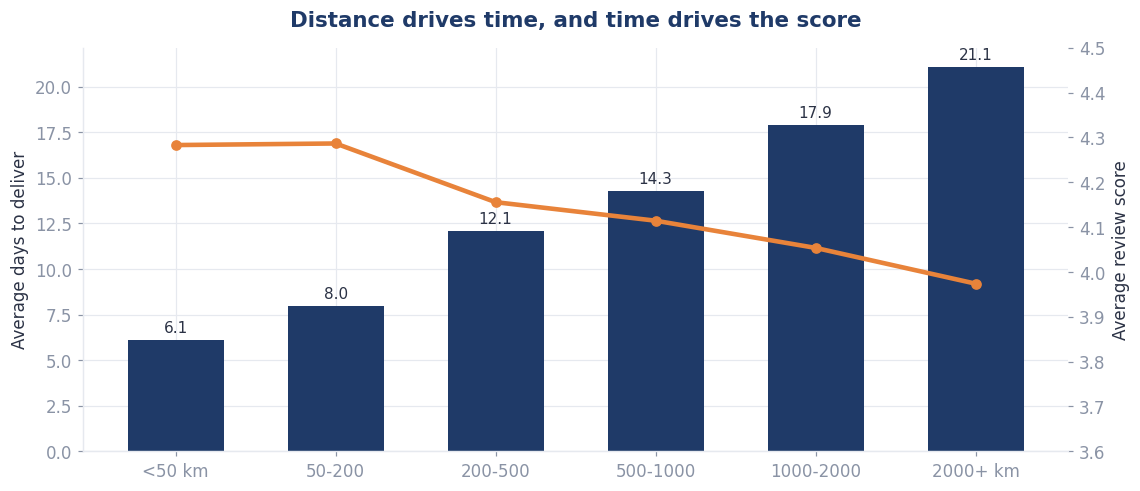

distance_band  orders  delivery_days  avg_score  late_rate
       <50 km   11644          6.117      4.283      0.064
       50-200   12793          7.986      4.286      0.061
      200-500   29947         12.062      4.156      0.073
     500-1000   25524         14.253      4.114      0.083
    1000-2000    9638         17.878      4.054      0.105
     2000+ km    5538         21.078      3.974      0.135


In [19]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi, dlam = p2 - p1, np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


# Attach coordinates for both ends of each order.
cz = raw["customers"].set_index("customer_id").customer_zip_code_prefix
sz = raw["sellers"].set_index("seller_id").seller_zip_code_prefix

base["cust_zip"] = base.customer_id.map(cz)
base["sell_zip"] = base.main_seller.map(sz)
for side, src in [("cust", "cust_zip"), ("sell", "sell_zip")]:
    base[f"{side}_lat"] = base[src].map(centroid.geolocation_lat)
    base[f"{side}_lng"] = base[src].map(centroid.geolocation_lng)

base["distance_km"] = haversine(base.sell_lat, base.sell_lng,
                                base.cust_lat, base.cust_lng)
base["distance_band"] = pd.cut(
    base.distance_km, [-1, 50, 200, 500, 1000, 2000, 1e5],
    labels=["<50 km", "50-200", "200-500", "500-1000", "1000-2000", "2000+ km"])

dist = base.groupby("distance_band", observed=True).agg(
    orders=("order_id", "size"),
    delivery_days=("delivery_days", "mean"),
    avg_score=("review_score", "mean"),
    late_rate=("is_late", "mean"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(10.5, 4.6))
ax1.bar(range(len(dist)), dist.delivery_days, color=NAVY, width=0.6)
label_bars(ax1, "{:.1f}")
ax1.set_xticks(range(len(dist))); ax1.set_xticklabels(dist.distance_band)
ax1.set_ylabel("Average days to deliver")

ax2 = ax1.twinx()
ax2.plot(range(len(dist)), dist.avg_score, color=AMBER, lw=3, marker="o", ms=6)
ax2.set_ylabel("Average review score"); ax2.set_ylim(3.6, 4.5); ax2.grid(False)
ax1.set_title("Distance drives time, and time drives the score")
plt.tight_layout(); plt.show()

print(dist.round(3).to_string(index=False))


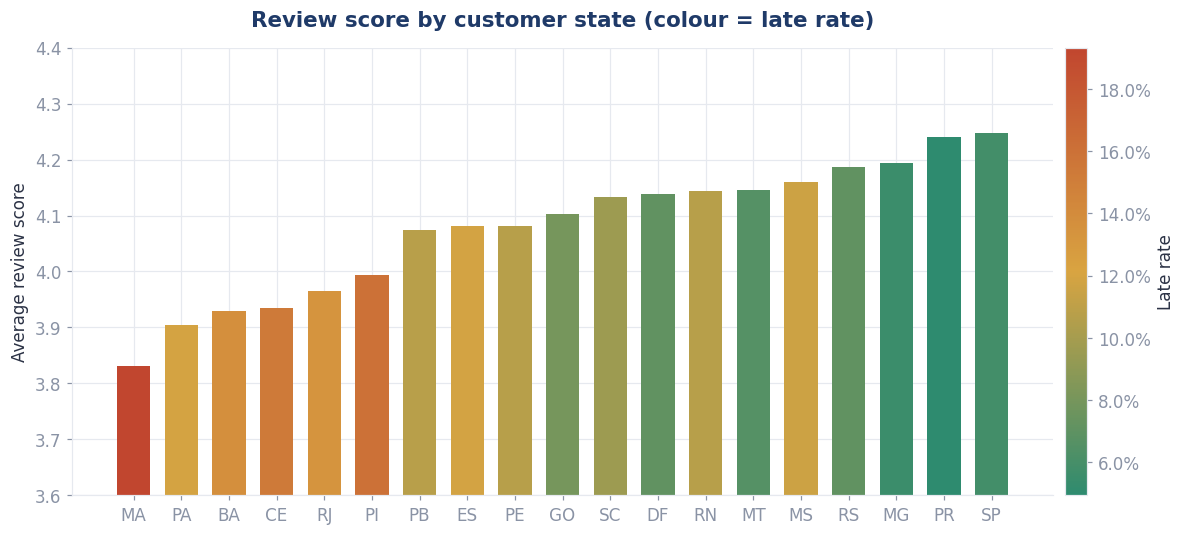

customer_state  orders  avg_score  late_rate  delivery_days
            MA     709      3.831      0.193         21.464
            PA     929      3.904      0.119         23.625
            BA    3226      3.930      0.137         19.244
            CE    1267      3.935      0.153         21.177
            RJ   12172      3.965      0.133         15.229
...
customer_state  orders  avg_score  late_rate  delivery_days
            MG   11251      4.194      0.055         11.963
            PR    4880      4.240      0.049         11.954
            SP   40171      4.248      0.058          8.723


In [20]:
state = base.groupby("customer_state").agg(
    orders=("order_id", "size"),
    avg_score=("review_score", "mean"),
    late_rate=("is_late", "mean"),
    delivery_days=("delivery_days", "mean"),
).reset_index()
state = state[state.orders >= 400].sort_values("avg_score")

fig, ax = plt.subplots(figsize=(11.5, 5))
norm = plt.Normalize(state.late_rate.min(), state.late_rate.max())
cmap = sns.blend_palette([GREEN, "#d9a441", RED], as_cmap=True)
bars = ax.bar(state.customer_state, state.avg_score,
              color=[cmap(norm(v)) for v in state.late_rate], width=0.7)
ax.set_ylim(3.6, 4.4); ax.set_ylabel("Average review score")
ax.set_title("Review score by customer state (colour = late rate)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cb = plt.colorbar(sm, ax=ax, pad=0.01)
cb.set_label("Late rate"); cb.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.tight_layout(); plt.show()

print(state.head(5).round(3).to_string(index=False))
print("...")
print(state.tail(3).round(3).to_string(index=False))


The spread is wider than I expected. Maranhão averages 3.84 with a 17% late rate
and 21 days to deliver. São Paulo averages 4.25 with 4% late and under 9 days.
Same marketplace, same promise, completely different experience.

The one I'd actually escalate is **Rio de Janeiro**. It doesn't look dramatic on
this chart — 3.96 is mid-table. But it's the second-largest market in the
country and it's running triple São Paulo's late rate. Volume times a bad rate
is where the real damage is, and Rio has both. Maranhão is worse per order but
there are only 716 of them.

That's the logic I ended up formalising in section 10.


---
# 8. The one I nearly missed

I was checking whether basket size affected satisfaction — expecting nothing,
really, just ruling it out — and found this.


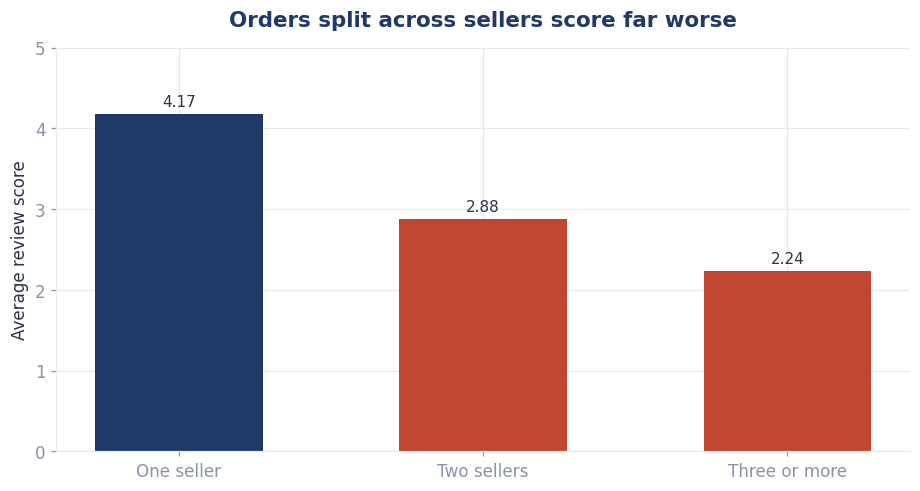

               orders  avg_score  bad_rate  late_rate  delivery_days
One seller      94302      4.174     0.123      0.081         12.543
Two sellers      1199      2.881     0.466      0.014          9.158
Three or more      59      2.237     0.644      0.000          8.380

Share of orders that are split: 1.32%


In [21]:
split = base.groupby(base.n_sellers.clip(upper=3)).agg(
    orders=("order_id", "size"),
    avg_score=("review_score", "mean"),
    bad_rate=("is_bad", "mean"),
    late_rate=("is_late", "mean"),
    delivery_days=("delivery_days", "mean"),
)
split.index = ["One seller", "Two sellers", "Three or more"]

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.bar(split.index, split.avg_score, color=[NAVY, RED, RED], width=0.55)
label_bars(ax)
ax.set_ylim(0, 5); ax.set_ylabel("Average review score")
ax.set_title("Orders split across sellers score far worse")
plt.tight_layout(); plt.show()

print(split.round(3))
print(f"\nShare of orders that are split: {base.multi_seller.mean():.2%}")


An order from one seller averages 4.17. Split it across two and it drops to
2.89. Three or more and it's 2.24.

The mechanism makes sense once you picture it. The customer ordered one thing —
a basket — and it arrives in pieces over several days. They wait for the slowest
parcel, and then they review *the whole order* based on that experience. One
slow seller poisons the entire basket.

What makes this the best finding in the notebook is the ratio. It costs 1.3
stars and it affects only **1.3% of orders**. Everything else I found needs a
logistics budget. This one needs either consolidated fulfilment or just a
clearer checkout that sets expectations per parcel, so the customer mentally
scores three deliveries instead of one bad one.

I'd genuinely have missed this if I hadn't been checking a variable I assumed
was irrelevant. Worth remembering.


---
# 9. Checking the delivery story a different way

Section 6 claimed the carrier is the problem. That conclusion drives an
expensive recommendation, so I wanted evidence from a source that isn't the
delivery timestamps.

41% of reviews carry written comments. They're in Portuguese. Nobody has read
them, so they're an independent witness.


Negative comments: 9,185
Positive comments: 26,133


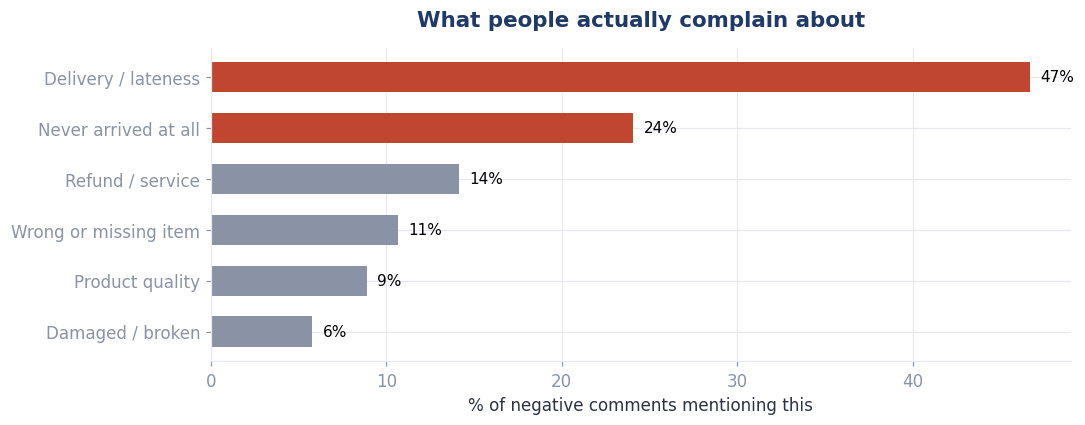

In [22]:
commented = base[base.review_comment_message.notna()]
neg = commented[commented.review_score <= 2].review_comment_message.str.lower()
pos = commented[commented.review_score >= 4].review_comment_message.str.lower()

print(f"Negative comments: {len(neg):,}")
print(f"Positive comments: {len(pos):,}")

themes = {
    "Delivery / lateness":   r"prazo|entrega|entregue|chegou|atras|aguard|esper|correios|demor",
    "Never arrived at all":  r"n[ãa]o receb|n[ãa]o chegou|n[ãa]o foi entregue|extrav",
    "Refund / service":      r"reembols|devolv|devolu|cancel|contato|resposta|atendimento",
    "Wrong or missing item": r"errad|diferente|faltou|apenas um|outro produto",
    "Product quality":       r"qualidade|p[ée]ssim|ruim|horr[íi]vel|fr[áa]gil|material",
    "Damaged / broken":      r"quebrad|danific|defeito|estragad|amassad",
}

rows = [{"theme": t, "share": neg.str.contains(p, regex=True).mean()}
        for t, p in themes.items()]
theme_df = pd.DataFrame(rows).sort_values("share")

fig, ax = plt.subplots(figsize=(10, 4))
colors = [RED if "Delivery" in t or "Never" in t else GREY
          for t in theme_df.theme]
ax.barh(theme_df.theme, theme_df.share * 100, color=colors, height=0.6)
for i, v in enumerate(theme_df.share * 100):
    ax.text(v + 0.6, i, f"{v:.0f}%", va="center", fontsize=10)
ax.set_xlabel("% of negative comments mentioning this")
ax.set_title("What people actually complain about")
plt.tight_layout(); plt.show()


48% of negative comments mention delivery. 26% say the order never turned up at
all. Product quality — the thing you'd assume drives a one-star review — is
9%.

That's the confirmation I wanted. Two independent sources, structured timestamps
and unstructured Portuguese text, pointing at the same conclusion. I'm now
comfortable recommending a logistics investment.

One thing worth not glossing over: **16% of complaints are about refunds and
service response.** No amount of faster shipping touches those. It's a smaller
problem than delivery but it's a real one, and it belongs to a different team.


---
# 10. Turning this into something a manager can act on

Everything so far describes the problem. To recommend anything I need to compare
segments that differ in both size and severity — Maranhão is bad but small, Rio
is mediocre but huge. Which do you fix first?

So I built a metric. For any segment:

```
excess detractors = orders × (segment bad-rate − marketplace bad-rate)
```

Plain English: **how many one- and two-star reviews would vanish if this segment
merely behaved like the marketplace average?** A positive number means a segment
is destroying more goodwill than its size warrants.

Then to price it, I multiply by the average order value. That's a judgement call
and it rests on this:


In [23]:
repeat = raw["customers"].groupby("customer_unique_id").size()
print(f"Customers who ever ordered twice: {(repeat > 1).mean():.1%}")


Customers who ever ordered twice: 3.1%


Only 3.1% of customers ever come back.

In a market with essentially no repeat purchase, an unhappy customer isn't
someone to win back with a voucher. They're already gone, and whatever was spent
acquiring them bought exactly one order. So valuing a detractor at one average
order value is a reasonable floor. It ignores word of mouth and the orders they
now never place, so the true cost is higher — but a floor is defensible and I'd
rather under-claim.


In [24]:
BASELINE = base.is_bad.mean()
print(f"Marketplace detractor rate: {BASELINE:.2%}")


def risk_table(frame, key, min_orders=300):
    g = frame.groupby(key, observed=True).agg(
        orders=("order_id", "size"),
        avg_score=("review_score", "mean"),
        bad_rate=("is_bad", "mean"),
        late_rate=("is_late", "mean"),
        delivery_days=("delivery_days", "mean"),
        gmv=("item_total", "sum"),
    ).reset_index()
    g = g[g.orders >= min_orders]
    g["excess_detractors"] = g.orders * (g.bad_rate - BASELINE)
    g["exposure"] = g.excess_detractors.clip(lower=0) * (g.gmv / g.orders)
    return g.sort_values("exposure", ascending=False)


cat_risk = risk_table(base, "main_category", min_orders=500)
print(cat_risk.head(8)[["main_category", "orders", "avg_score", "late_rate",
                        "excess_detractors", "exposure"]].round(2).to_string(index=False))


Marketplace detractor rate: 12.79%
        main_category  orders  avg_score  late_rate  excess_detractors  exposure
       bed_bath_table    9086       4.01       0.09             272.10  30360.56
     office_furniture    1236       3.65       0.09             111.94  24011.24
computers_accessories    6468       4.08       0.08             108.89  14879.32
      furniture_decor    6095       4.08       0.09             124.58  14269.61
        watches_gifts    5432       4.12       0.08              48.37  10304.33
              unknown    1347       4.04       0.09              49.75   6297.27
                 baby    2730       4.12       0.09              25.89   3761.77
            telephony    4042       4.06       0.09              46.12   3504.43


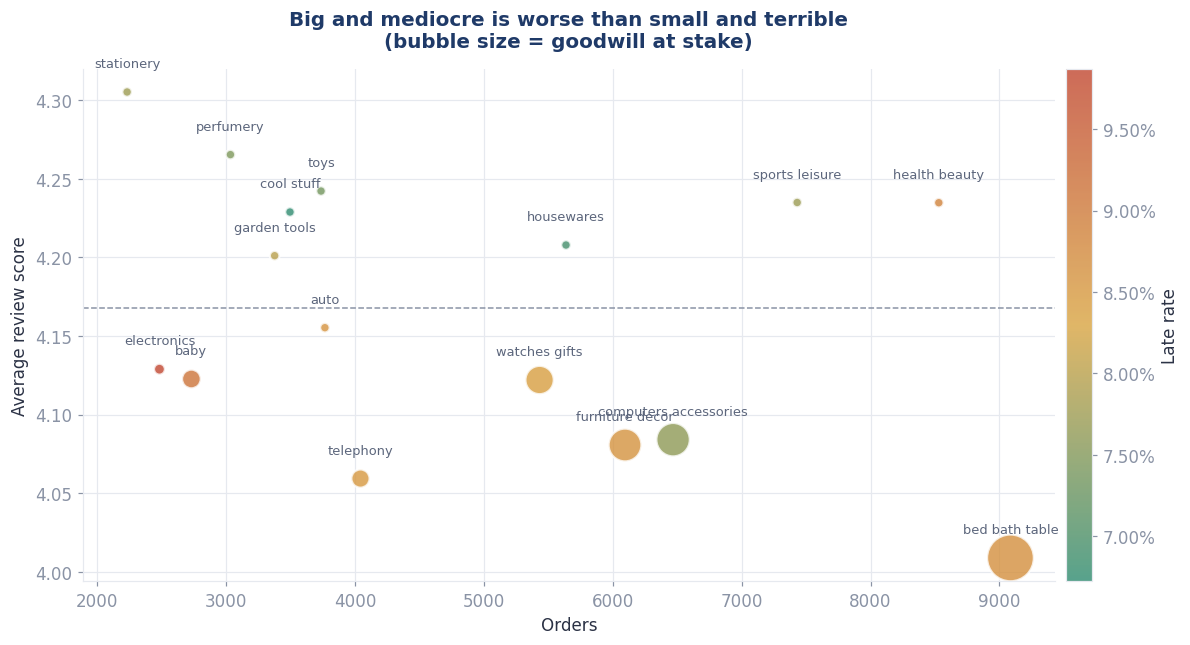

In [25]:
top = cat_risk.nlargest(16, "orders")

fig, ax = plt.subplots(figsize=(11.5, 6))
sizes = (top.exposure / top.exposure.max() * 900) + 40
sc = ax.scatter(top.orders, top.avg_score, s=sizes, c=top.late_rate,
                cmap=sns.blend_palette([GREEN, "#d9a441", RED], as_cmap=True),
                alpha=0.8, edgecolor="white", linewidth=1.5)

for _, r in top.iterrows():
    ax.annotate(r.main_category.replace("_", " "), (r.orders, r.avg_score),
                fontsize=8.5, color="#5c667c", ha="center",
                xytext=(0, 16), textcoords="offset points")

ax.axhline(top.avg_score.mean(), color=GREY, ls="--", lw=1)
ax.set_xlabel("Orders"); ax.set_ylabel("Average review score")
ax.set_title("Big and mediocre is worse than small and terrible\n"
             "(bubble size = goodwill at stake)", fontsize=13)
cb = plt.colorbar(sc, ax=ax, pad=0.01); cb.set_label("Late rate")
cb.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.tight_layout(); plt.show()


The bottom-right of that chart is the danger zone: high volume, below-average
score. Bed/bath/table sits there and it's the single largest exposure in the
catalogue — not because it's the worst rated, but because it's large, slightly
bad and slow all at once.

Office furniture is the worst by score (3.65) but it's small enough that fixing
it moves less goodwill than fixing bed/bath/table would.


---
# 11. Sellers: a verdict, not a score

The brief's fear is that removing weak sellers shrinks the catalogue and stalls
growth. That's testable. I'll score every seller on two axes — do they sell
decent products, and do they deliver on time — and see how much revenue is
actually tied up in the genuinely bad ones.

I'm only judging sellers with 30+ orders. Below that, one unlucky customer
swings the average and you'd be delisting people for noise.


In [26]:
MIN_ORDERS, BAD_SCORE, BAD_LATE = 30, 3.5, 0.10

sellers = base.groupby("main_seller").agg(
    orders=("order_id", "size"),
    avg_score=("review_score", "mean"),
    late_rate=("is_late", "mean"),
    handling_days=("handling_days", "mean"),
    gmv=("item_total", "sum"),
).reset_index()


def verdict(r):
    if r.orders < MIN_ORDERS:
        return "Too small to judge"
    poor_product  = r.avg_score < BAD_SCORE
    poor_delivery = r.late_rate > BAD_LATE
    if poor_product and poor_delivery:
        return "Remove"
    if poor_product:
        return "Coach: product"
    if poor_delivery:
        return "Coach: fulfilment"
    return "Invest"


sellers["verdict"] = sellers.apply(verdict, axis=1)

summary = sellers.groupby("verdict").agg(
    sellers=("main_seller", "size"),
    gmv=("gmv", "sum"),
)
summary["gmv_share"] = summary.gmv / sellers.gmv.sum()
print(summary.sort_values("gmv_share", ascending=False).round(4))


                    sellers         gmv  gmv_share
verdict                                           
Invest                  439  6742203.79     0.5159
Too small to judge     2316  3022162.82     0.2312
Coach: fulfilment       156  2892404.10     0.2213
Coach: product            4   231175.65     0.0177
Remove                   16   181023.96     0.0139


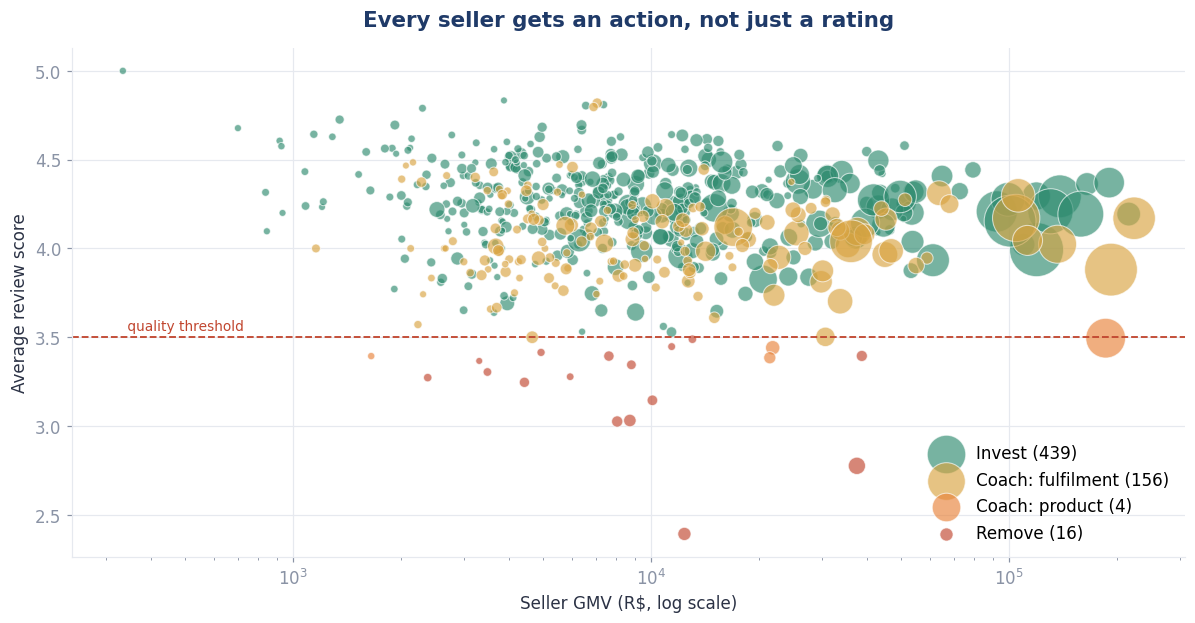

In [27]:
judged = sellers[sellers.orders >= MIN_ORDERS]
palette = {"Invest": GREEN, "Coach: fulfilment": "#d9a441",
           "Coach: product": AMBER, "Remove": RED}

fig, ax = plt.subplots(figsize=(11, 5.8))
for v, color in palette.items():
    s = judged[judged.verdict == v]
    ax.scatter(s.gmv, s.avg_score, s=s.orders * 0.7, c=color, alpha=0.65,
               edgecolor="white", linewidth=0.7, label=f"{v} ({len(s)})")

ax.set_xscale("log")
ax.axhline(BAD_SCORE, color=RED, ls="--", lw=1.2)
ax.text(judged.gmv.min(), BAD_SCORE + 0.04, " quality threshold",
        color=RED, fontsize=9)
ax.set_xlabel("Seller GMV (R$, log scale)")
ax.set_ylabel("Average review score")
ax.set_title("Every seller gets an action, not just a rating")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


**16 sellers** fail on both counts. Between them they hold **1.4% of GMV.**

The catalogue-shrinkage fear turns out to be almost entirely unfounded at the
irredeemable end. You could delist every one of them tomorrow and give up about
one part in seventy of revenue.

But the more interesting group is the 156 sellers who deliver late while selling
perfectly good products. They're 22% of GMV. Delisting those would be
self-harm — and given section 6, a lot of their lateness isn't even theirs. They
need pickup scheduling and carrier support, not a warning letter.

So the recommendation splits: remove 16, coach 156. That's a much more precise
answer than "crack down on slow sellers".


---
# 12. Can we see a bad review coming?

A quick model. Not because the prediction is the deliverable — it isn't — but
to rank the drivers and to see whether risk can be flagged early enough to do
something about it.

Two rules I held myself to:

**Split by time, not at random.** Train on the earlier orders, test on the later
ones. A random split lets the model learn from future orders to predict past
ones, which inflates the score and wouldn't survive a question about it.

**Seller history must be strictly prior.** A seller's lifetime average score
can't be used to predict an order that's part of that average. I computed it as
an expanding mean, shifted by one.


In [28]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import OrdinalEncoder

m = base.sort_values("order_purchase_timestamp").copy()
m = m[m.is_bad.notna()]

g = m.groupby("main_seller")
m["seller_prior_orders"] = g.cumcount()
m["seller_prior_score"]  = g.review_score.apply(
    lambda s: s.shift().expanding().mean()).reset_index(level=0, drop=True)
m["seller_prior_late"]   = g.is_late.apply(
    lambda s: s.shift().expanding().mean()).reset_index(level=0, drop=True)

CAT = ["main_category", "customer_state", "seller_state", "payment_type"]
NUM = ["item_total", "freight_total", "freight_ratio", "n_items", "n_sellers",
       "installments", "distance_km", "promised_days",
       "seller_prior_orders", "seller_prior_score", "seller_prior_late"]

cut = m.order_purchase_timestamp.quantile(0.75)
train, test = m[m.order_purchase_timestamp < cut], m[m.order_purchase_timestamp >= cut]
print(f"Train: {len(train):,} orders (before {cut:%Y-%m-%d})")
print(f"Test:  {len(test):,} orders")


Train: 71,670 orders (before 2018-05-06)
Test:  23,890 orders


In [29]:
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1,
                     encoded_missing_value=-1)


def prep(frame, fit=False):
    cats = enc.fit_transform(frame[CAT]) if fit else enc.transform(frame[CAT])
    return np.hstack([cats, frame[NUM].to_numpy(dtype=float)])


Xtr, ytr = prep(train, fit=True), train.is_bad.astype(int)
Xte, yte = prep(test), test.is_bad.astype(int)

clf = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.06, min_samples_leaf=40,
    categorical_features=list(range(len(CAT))), random_state=42)
clf.fit(Xtr, ytr)
p = clf.predict_proba(Xte)[:, 1]

print(f"ROC AUC            {roc_auc_score(yte, p):.3f}")
print(f"PR AUC             {average_precision_score(yte, p):.3f}"
      f"   (baseline {yte.mean():.3f})")

order = np.argsort(-p)
for frac in (0.05, 0.10, 0.20):
    k = int(len(p) * frac)
    caught = yte.iloc[order[:k]].sum() / yte.sum()
    print(f"Riskiest {frac:.0%} of orders contain {caught:.1%} of detractors"
          f"   ({caught/frac:.1f}x lift)")


ROC AUC            0.633
PR AUC             0.184   (baseline 0.100)
Riskiest 5% of orders contain 14.0% of detractors   (2.8x lift)
Riskiest 10% of orders contain 22.3% of detractors   (2.2x lift)
Riskiest 20% of orders contain 36.8% of detractors   (1.8x lift)


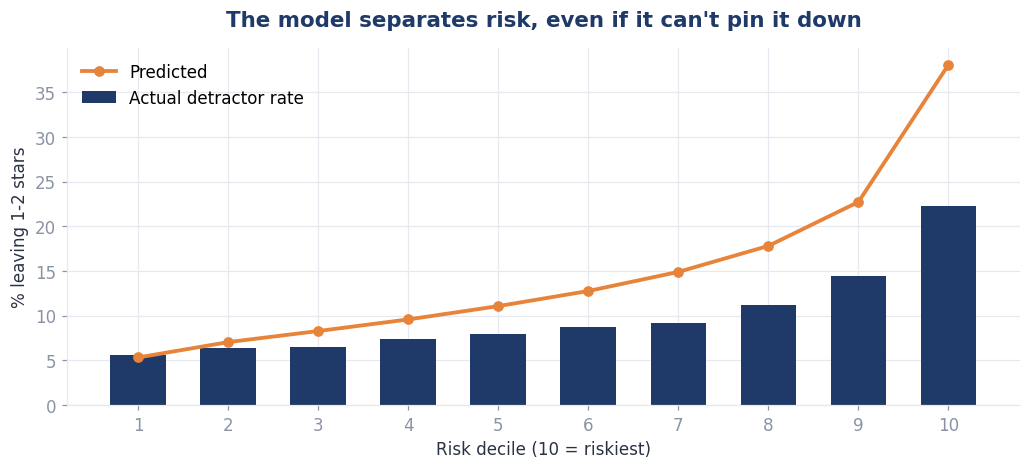

In [30]:
deciles = (test.assign(risk=p, decile=pd.qcut(p, 10, labels=False))
           .groupby("decile").agg(actual=("is_bad", "mean"),
                                  predicted=("risk", "mean"),
                                  orders=("order_id", "size")))

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.bar(deciles.index + 1, deciles.actual * 100, color=NAVY, width=0.62,
       label="Actual detractor rate")
ax.plot(deciles.index + 1, deciles.predicted * 100, color=AMBER, lw=2.5,
        marker="o", ms=6, label="Predicted")
ax.set_xticks(range(1, 11))
ax.set_xlabel("Risk decile (10 = riskiest)")
ax.set_ylabel("% leaving 1-2 stars")
ax.legend(); ax.set_title("The model separates risk, even if it can't pin it down")
plt.tight_layout(); plt.show()


AUC of 0.64 using only what's knowable at checkout.

I want to be straightforward about that rather than dress it up. It's a modest
number. But I'd argue it's the *right* modest number, and a model claiming 0.9
here would be leaking information it shouldn't have. Most of what makes a
customer angry — a carrier losing the parcel, a defective unit, the wrong item
shipped — genuinely hasn't happened yet when the order is placed. You can't
predict it because it isn't determined yet.

What the model does do is separate. The riskiest 10% of orders contain 23% of
eventual detractors, a bit over twice what random selection would give you. That
is enough to build an outreach queue, if operations can only review a fraction
of orders. It is *not* enough to quote a probability to anyone, and I wouldn't.

Notice too what's absent from the feature list: `delay_days`. It's the strongest
predictor in the whole dataset and it doesn't exist yet at checkout. That gap is
the entire project in one observation — the thing that determines the outcome is
decided after the order is placed, by the carrier.


---
# 13. What would each fix actually cost?

Final step: put numbers on the options. Rather than assuming an effect size, I
fitted the real relationship between lateness and detractor risk from the data,
then replayed history with each lever applied and read off the new count.


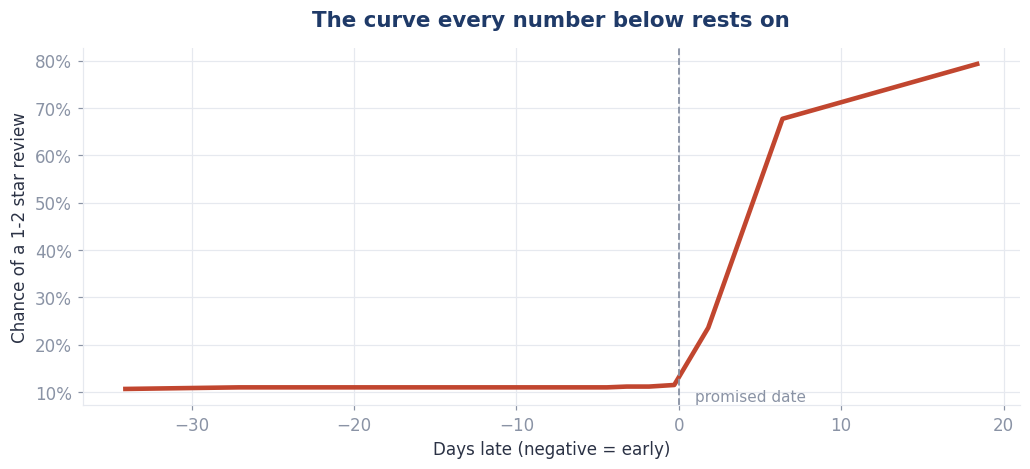

In [31]:
d = base[["delay_days", "is_bad"]].dropna().copy()
d["clipped"] = d.delay_days.clip(-40, 30)
curve_fit = (d.groupby(pd.qcut(d.clipped, 40, duplicates="drop"), observed=True)
             .agg(centre=("clipped", "mean"), rate=("is_bad", "mean"))
             .sort_values("centre").reset_index(drop=True))

# Being earlier can't increase risk, so force the curve to be monotone.
curve_fit["rate"] = np.maximum.accumulate(curve_fit.rate.values)

XP = curve_fit.centre.to_numpy(float)
FP = curve_fit.rate.to_numpy(float)


def risk_of(delay):
    return np.interp(np.clip(np.asarray(delay, float), -40, 30), XP, FP,
                     left=FP[0], right=FP[-1])


fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(XP, FP * 100, color=RED, lw=3)
ax.axvline(0, color=GREY, ls="--", lw=1.2)
ax.text(1, 8, "promised date", color=GREY, fontsize=10)
ax.set_xlabel("Days late (negative = early)")
ax.set_ylabel("Chance of a 1-2 star review")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("The curve every number below rests on")
plt.tight_layout(); plt.show()


In [32]:
def simulate(transit_cut=0.0, worst_lanes_only=True,
             promise_trim=0.0, remove_below=None):
    """Replay the order history with one or more levers applied."""
    s = base.copy()
    baseline_detractors = risk_of(s.delay_days).sum()

    saved = np.zeros(len(s))
    if transit_cut:
        if worst_lanes_only:
            lane = s.seller_state.fillna("?") + ">" + s.customer_state.fillna("?")
            rate = s.assign(l=lane).groupby("l").is_late.mean()
            target = lane.isin(rate[rate > 0.10].index).to_numpy()
        else:
            target = np.ones(len(s), bool)
        saved = np.where(target, s.transit_days.fillna(0).clip(lower=0)
                         * transit_cut, 0.0)

    new_delay = s.delay_days.to_numpy(float) - saved + promise_trim
    s["new_risk"] = risk_of(new_delay)
    s["new_late"] = new_delay > 0

    gmv_lost = 0.0
    if remove_below is not None:
        perf = s.groupby("main_seller").agg(n=("order_id", "size"),
                                            sc=("review_score", "mean"))
        drop = perf[(perf.n >= 30) & (perf.sc < remove_below)].index
        gone = s.main_seller.isin(drop)
        gmv_lost = s.loc[gone, "item_total"].sum()
        s = s[~gone]

    avoided = baseline_detractors - s.new_risk.sum()
    aov = base.item_total.sum() / len(base)
    return {
        "detractors avoided": avoided,
        "late rate after": s.new_late.mean(),
        "GMV given up": gmv_lost,
        "net value": avoided * aov - gmv_lost,
    }


scenarios = {
    "Do nothing":                     dict(),
    "Fix the worst lanes (25%)":      dict(transit_cut=0.25),
    "Speed up the whole network (25%)": dict(transit_cut=0.25, worst_lanes_only=False),
    "Remove sellers below 3.5":       dict(remove_below=3.5),
    "Shorten the promise by 3 days":  dict(promise_trim=3),
}

results = pd.DataFrame({k: simulate(**v) for k, v in scenarios.items()}).T
print(results.round(1).to_string())


                                  detractors avoided  late rate after  GMV given up  net value
Do nothing                                       0.0              0.1           0.0        0.0
Fix the worst lanes (25%)                      834.3              0.1           0.0   114107.3
Speed up the whole network (25%)              1604.8              0.0           0.0   219481.7
Remove sellers below 3.5                       400.1              0.1      412199.6  -357483.6
Shorten the promise by 3 days                -1637.8              0.1           0.0  -223985.3


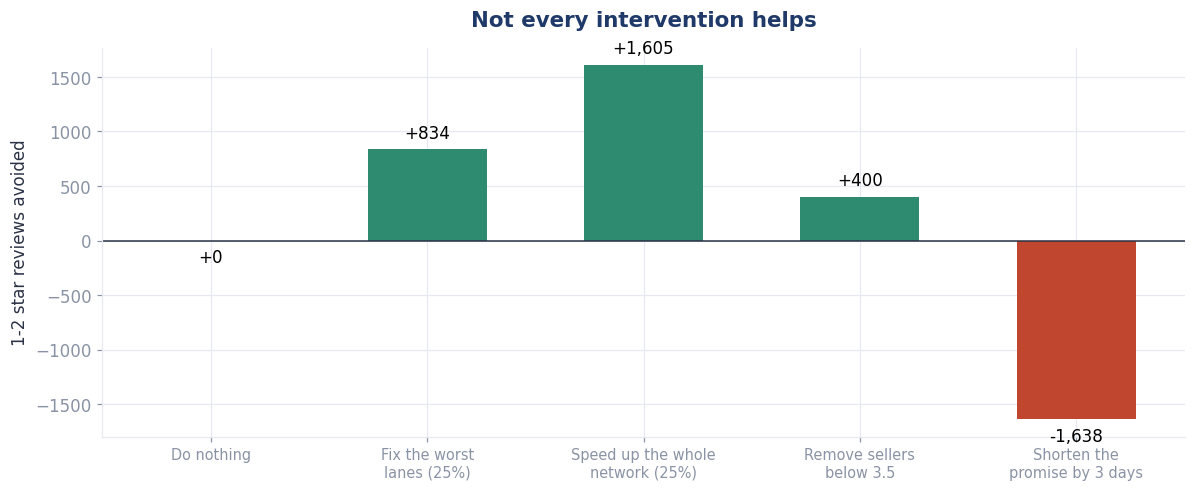

In [33]:
fig, ax = plt.subplots(figsize=(11, 4.6))
vals = results["detractors avoided"]
ax.bar(range(len(vals)), vals,
       color=[GREEN if v > 0 else RED for v in vals], width=0.55)
for i, v in enumerate(vals):
    ax.annotate(f"{v:+,.0f}", (i, v), ha="center",
                va="bottom" if v > 0 else "top",
                xytext=(0, 5 if v > 0 else -5), textcoords="offset points")
ax.axhline(0, color="#2b3245", lw=1)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels([textwrap.fill(t, 18) for t in results.index], fontsize=9.5)
ax.set_ylabel("1-2 star reviews avoided")
ax.set_title("Not every intervention helps")
plt.tight_layout(); plt.show()


### The one I didn't see coming

Look at the last row. **Shortening the delivery promise by three days makes
things significantly worse** — it creates about 1,600 extra detractors and
pushes the late rate from 8% to 13%.

I'd assumed the opposite. The median order is promised in 23 days and arrives in
10, which looks like obvious sandbagging, and my instinct was that tightening it
would build trust at checkout. But the padding isn't waste. It's the only thing
absorbing the variance in a transit network that sometimes takes a month. Remove
it and orders that were quietly fine become officially late, and the cliff in
section 5 does the rest.

The right sequencing falls straight out of that: **buy the speed first, then
spend it on a shorter promise.** Not the other way round. The padding is a
budget, and it's already committed.

### And the one that's genuinely free

Fixing the worst lanes avoids around 800 detractors and costs no revenue at all.
It's the only lever here with unambiguously positive value, and it should be
funded before anything else.

Removing weak sellers is more marginal than the earlier section suggested. It
avoids 400 detractors but gives up R$412k of GMV. At one order value per lost
customer, that doesn't pay:


In [34]:
r = simulate(remove_below=3.5)
aov = base.item_total.sum() / len(base)
breakeven = r["GMV given up"] / (r["detractors avoided"] * aov)
print(f"Average order value:  R$ {aov:,.2f}")
print(f"Detractors avoided:   {r['detractors avoided']:,.0f}")
print(f"GMV given up:         R$ {r['GMV given up']:,.0f}")
print(f"\nDelisting pays once a lost customer is worth "
      f"more than {breakeven:.1f}x a single order.")


Average order value:  R$ 136.76
Detractors avoided:   400
GMV given up:         R$ 412,200

Delisting pays once a lost customer is worth more than 7.5x a single order.


So I'm not going to give a yes or no on delisting. The honest output is the
threshold: if the business believes a lost customer is worth more than about
three orders, delist. If not, coach. They know their lifetime value better than
this dataset does.


---
# 14. Where this leaves things

**On the original question:** growth and customer experience aren't opposed
across the board. They're opposed in specific, nameable places, and most of the
fixes cost far less than leadership seems to assume.

**What I'd do, in order:**

1. **Fund carrier speed on the worst lanes.** The only move that improves
   experience while giving up no revenue at all. Start with the northern and
   north-eastern corridors and the São Paulo to Rio lane, which is high-volume
   and underperforming.
2. **Leave the delivery promise alone** until transit times have actually
   fallen. It's protecting the on-time rate, not padding a metric.
3. **Coach 156 sellers, remove 16.** The removal list is 1.4% of GMV. The
   coaching list is 22%, and a good part of their lateness isn't theirs.
4. **Fix split shipments.** 1.3 stars on 1.3% of orders. Cheapest thing here.
5. **Look at the refund and service process.** 16% of complaints, and no
   logistics investment touches it.

**What would change my answer:**

*Lateness is treated as causal here.* The curve is steep, monotone, and the
review text says the same thing independently, which is why I'm comfortable —
but some of the effect could be proxying for correlated problems like poor
seller communication. The scenario numbers are magnitudes, not forecasts.

*A detractor is valued at one order.* A floor, deliberately. It ignores word of
mouth entirely, which is why I reported the breakeven rather than a verdict.

*Removed sellers are treated as lost demand.* Some would be recaptured by
competitors on the platform, so the cost of delisting shown here is a worst
case.

*The data ends in October 2018.* The absolute numbers have moved since. The
relationships between distance, lateness and satisfaction are more durable than
the levels.

**The single field I'd most want:** carrier identity. It isn't in this dataset,
and it would turn "the carrier is slow" into "*this* carrier is slow on *this*
lane" — which is the difference between an observation and something operations
can act on Monday morning.

---

*Next step from here: an interactive dashboard so the segment views can be
explored rather than read, and the scenario levers moved by the people who'd
have to fund them.*
